In [1]:
import numpy as np
from dataclasses import dataclass
from functools import partial

import matplotlib.pyplot as plt
from matplotlib import rc
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)

import torch

from lingua.optim import build_optimizer, OptimArgs

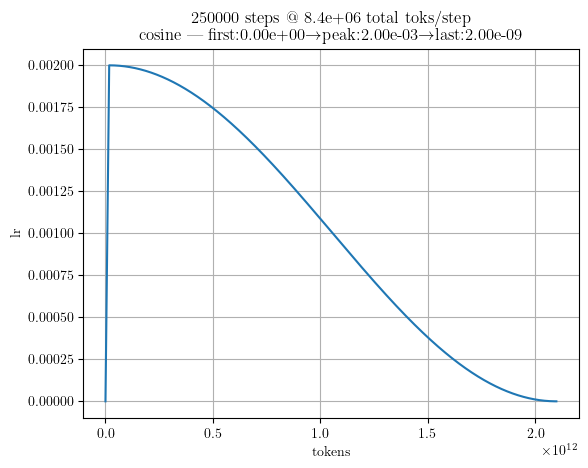

In [2]:
# now plot the lr as a function of step

# overrides = {
#     "scheduler": "cosine",
#     "warmup": 2000,
#     "lr": 1.0e-3,
#     "lr_min_ratio": 0.000001,
# }
# overrides = {
#     "scheduler": "cosine",
#     "warmup": 2000,
#     "lr": 3.0e-4,
#     "lr_min_ratio": 1.0e-1,
# }
# overrides = {
#     "scheduler": "wsd",
#     "warmup": 2000,
#     "lr": 3.0e-4,
#     "lr_min_ratio": 1.0e-4,
#     "decay_fraction": 1.0e-1, # fraction of the total steps for decay
# }
# overrides = {
#     "scheduler": "wsd",
#     "warmup": 2000,
#     "lr": 3.0e-4,
#     "lr_min_ratio": 1.0e-4,
#     "decay_fraction": 3.33333e-1,
# }
overrides = {
    "scheduler": "cosine",
    "warmup": 2000,
    "lr": 2.0e-3,
    "lr_min_ratio": 0.000001,
}
args = OptimArgs(**overrides)

# n_steps = 125_000
n_steps = 250_000
# toks_per_step = args.grad_acc_steps * args.data.batch_size * args.data.seq_len
toks_per_step_world = 1 * (128*4*4) * 4096

# fake model with one parameter
class FakeModule(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = torch.nn.Linear(10, 10)

    def forward(self, x):
        return x
    def __repr__(self):
        return "fake model"
model = FakeModule()

optimizer, scheduler = build_optimizer(model, args, n_steps)

# all_lrs = [lr_fn(i) for i in range(n_steps)]
all_lrs = []
for i in range(n_steps):
    all_lrs.append(optimizer.param_groups[0]["lr"])
    optimizer.step()
    scheduler.step()

x = np.arange(n_steps)
x = x * toks_per_step_world
y = np.array(all_lrs)
plt.plot(x, y)
plt.xlabel("tokens")
plt.ylabel("lr")
arrow = r"$\rightarrow$"
plt.title(f"{n_steps} steps @ {toks_per_step_world:.1e} total toks/step\n{args.scheduler} | first:{all_lrs[0]:.2e}{arrow}peak:{max(all_lrs):.2e}{arrow}last:{all_lrs[-1]:.2e}")
plt.grid()
plt.savefig(f"lr_scheduler_{args.scheduler}.png")